# SHA-256 Input-to-Output Transfer Grammar

## $\tau(M)\rightarrow \Delta B(H)$

This notebook keeps the gaze on the outside of SHA:

$$
\boxed{\text{input shape}\rightarrow\text{output shape}}
$$

Instead of trying to recover unavailable internal states, it treats SHA-256 as a transfer surface and measures how controlled input transformations echo in digest behavior.

Core object:

$$
\boxed{
\Delta B_H(\tau;M)=B(H(\tau(M)))-B(H(M))
}
$$

where:

- $M$ is an input message.
- $\tau$ is an input transformation / verb.
- $H(M)=\operatorname{SHA256}(M)$.
- $B(H)$ is a digest-behavior feature vector.

The goal is not generic inversion. The goal is to build the **transfer grammar**:

$$
\boxed{
G_{\text{SHA}}=\{(\tau,\Delta B_H)\}
}
$$


In [1]:
# Top cell: imports and global settings

import hashlib
import math
import random
from typing import Callable, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260501
random.seed(SEED)
np.random.seed(SEED)

N_BASE = 64          # base messages per domain
MSG_LEN = 64         # fixed message length for clean comparisons
AUTOCORR_LAGS = 16
TOP_TRANSFORMS_TO_DISPLAY = 20

print("Notebook initialized.")
print(f"SEED={SEED}, N_BASE={N_BASE}, MSG_LEN={MSG_LEN}")


Notebook initialized.
SEED=20260501, N_BASE=64, MSG_LEN=64


## 1. Digest behavior vector $B(H)$

For a digest byte vector:

$$
d=(d_0,\dots,d_{31})
$$

we compute entropy, bit density, byte-lag autocorrelation, sign-change count, and crude typeless byte-stream probes. These probes expose output-shape changes; they are not claims that digests are executable programs.


In [2]:
# Digest and feature utilities

def sha256_bytes(msg: bytes) -> bytes:
    return hashlib.sha256(msg).digest()

def byte_entropy(bs: bytes) -> float:
    counts = np.bincount(np.frombuffer(bs, dtype=np.uint8), minlength=256)
    p = counts[counts > 0] / len(bs)
    return float(-(p * np.log2(p)).sum())

def digest_autocorr(bs: bytes, max_lag: int = AUTOCORR_LAGS) -> np.ndarray:
    x = np.frombuffer(bs, dtype=np.uint8).astype(float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    if denom == 0:
        return np.zeros(max_lag)
    vals = []
    for lag in range(1, max_lag + 1):
        vals.append(float(np.dot(x[:-lag], x[lag:]) / denom))
    return np.array(vals, dtype=float)

def sign_changes(v: np.ndarray) -> int:
    s = np.sign(v)
    nonzero = s[s != 0]
    if len(nonzero) < 2:
        return 0
    return int(np.sum(nonzero[:-1] * nonzero[1:] < 0))

def byte_bit_density(bs: bytes) -> float:
    return sum(int(b).bit_count() for b in bs) / (8 * len(bs))

def opcode_proxy_features(bs: bytes) -> Dict[str, float]:
    arr = list(bs)
    n = len(arr)
    if n == 0:
        return {
            "x86_ctrl_proxy": 0.0,
            "x86_stack_proxy": 0.0,
            "ascii_printable_proxy": 0.0,
            "zero_ff_nop_proxy": 0.0,
            "byte_repeat_proxy": 0.0,
        }

    ctrl = sum(
        (0x70 <= b <= 0x7F) or b in {0xE8, 0xE9, 0xEB, 0xC2, 0xC3, 0xCA, 0xCB, 0xCC}
        for b in arr
    ) / n
    stack = sum(
        b in {0x50,0x51,0x52,0x53,0x54,0x55,0x56,0x57,0x58,0x59,0x5A,0x5B,0x5C,0x5D,0x5E,0x5F}
        for b in arr
    ) / n
    printable = sum(32 <= b <= 126 for b in arr) / n
    flat = sum(b in {0x00, 0x90, 0xFF} for b in arr) / n
    repeat_pairs = sum(arr[i] == arr[i-1] for i in range(1, n)) / max(1, n-1)

    return {
        "x86_ctrl_proxy": float(ctrl),
        "x86_stack_proxy": float(stack),
        "ascii_printable_proxy": float(printable),
        "zero_ff_nop_proxy": float(flat),
        "byte_repeat_proxy": float(repeat_pairs),
    }

def B_of_digest(digest: bytes) -> Dict[str, float]:
    arr = np.frombuffer(digest, dtype=np.uint8).astype(float)
    ac = digest_autocorr(digest, AUTOCORR_LAGS)
    feats = {
        "entropy": byte_entropy(digest),
        "byte_mean": float(arr.mean()),
        "byte_std": float(arr.std()),
        "bit_density": byte_bit_density(digest),
        "ac_sign_changes": float(sign_changes(ac)),
        "ac_energy": float(np.dot(ac, ac)),
        "ac_abs_mean": float(np.mean(np.abs(ac))),
        "lag1": float(ac[0]),
        "lag2": float(ac[1]),
        "lag4": float(ac[3]),
        "lag8": float(ac[7]),
        "lag16": float(ac[15]),
    }
    for i, val in enumerate(ac, start=1):
        feats[f"ac_{i:02d}"] = float(val)
    feats.update(opcode_proxy_features(digest))
    return feats

def B_of_msg(msg: bytes) -> Dict[str, float]:
    return B_of_digest(sha256_bytes(msg))

sample = b"abc"
feats = B_of_msg(sample)
print("Feature count:", len(feats))
print("Digest:", sha256_bytes(sample).hex())
print({k: round(feats[k], 4) for k in ["entropy", "bit_density", "ac_sign_changes", "lag1", "x86_ctrl_proxy"]})


Feature count: 33
Digest: ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad
{'entropy': 4.875, 'bit_density': 0.4688, 'ac_sign_changes': 7.0, 'lag1': -0.3042, 'x86_ctrl_proxy': 0.0625}


## 2. Input generators: source measures $\mu_D$

We generate fixed-length base messages from several source measures:

$$
M\sim \mu_D
$$


In [3]:
# Input source measures

WORDS = (
    "the quick brown fox jumps over lazy dog nexus phase fold shape signal "
    "cipher lattice matrix carry scar grammar recursion input output transfer "
).split()

CODE_TOKENS = [
    b"push", b"mov", b"xor", b"add", b"sub", b"jmp", b"call", b"ret",
    b"cmp", b"jne", b"loop", b"int", b"nop", b"lea", b"shr", b"ror",
]

def fix_len(bs: bytes, n: int = MSG_LEN) -> bytes:
    if len(bs) >= n:
        return bs[:n]
    return bs + bytes([0]) * (n - len(bs))

def gen_random(n: int = MSG_LEN) -> bytes:
    return bytes(random.getrandbits(8) for _ in range(n))

def gen_zero(n: int = MSG_LEN) -> bytes:
    return bytes([0]) * n

def gen_nop(n: int = MSG_LEN) -> bytes:
    return bytes([0x90]) * n

def gen_ff(n: int = MSG_LEN) -> bytes:
    return bytes([0xFF]) * n

def gen_repeated_byte(n: int = MSG_LEN) -> bytes:
    b = random.randrange(256)
    return bytes([b]) * n

def gen_repeated_word(n: int = MSG_LEN) -> bytes:
    w = random.getrandbits(32).to_bytes(4, "big")
    return (w * ((n + 3) // 4))[:n]

def gen_text(n: int = MSG_LEN) -> bytes:
    out = []
    while len(" ".join(out).encode()) < n:
        out.append(random.choice(WORDS))
    return fix_len(" ".join(out).encode(), n)

def gen_code_like(n: int = MSG_LEN) -> bytes:
    out = bytearray()
    while len(out) < n:
        tok = random.choice(CODE_TOKENS)
        out.extend(tok)
        out.append(random.choice([0x20, 0x0A, 0x3B, 0x00, 0x90]))
    return bytes(out[:n])

def gen_tone(n: int = MSG_LEN) -> bytes:
    phase = random.random() * 2 * math.pi
    freq = random.choice([1, 2, 3, 5, 8])
    vals = []
    for i in range(n):
        v = 128 + 80 * math.sin(2 * math.pi * freq * i / n + phase)
        vals.append(int(max(0, min(255, round(v)))))
    return bytes(vals)

GENERATORS: Dict[str, Callable[[int], bytes]] = {
    "random": gen_random,
    "zero": gen_zero,
    "nop": gen_nop,
    "ff": gen_ff,
    "repeated_byte": gen_repeated_byte,
    "repeated_word": gen_repeated_word,
    "text": gen_text,
    "code_like": gen_code_like,
    "tone": gen_tone,
}

base_rows = []
base_messages = []
for domain, gen in GENERATORS.items():
    for i in range(N_BASE):
        msg = gen(MSG_LEN)
        base_messages.append((domain, i, msg))
        row = {"domain": domain, "idx": i, "msg_hex": msg.hex()}
        row.update(B_of_msg(msg))
        base_rows.append(row)

base_df = pd.DataFrame(base_rows)
print("Base dataset:", base_df.shape)
base_df.groupby("domain")[["entropy", "ac_sign_changes", "ac_energy", "x86_ctrl_proxy"]].mean().round(4)


Base dataset: (576, 36)


,entropy,ac_sign_changes,ac_energy,x86_ctrl_proxy
domain,,,,
code_like,4.8789,7.2812,0.3731,0.0913
ff,4.8750,6.0000,0.1582,0.1250
nop,4.9375,5.0000,0.3401,0.0312
random,4.8755,7.7031,0.3748,0.0884
repeated_byte,4.8848,7.4375,0.3871,0.1001
repeated_word,4.8774,7.4688,0.3487,0.0996
text,4.8823,7.7500,0.3697,0.0913
tone,4.8650,7.5781,0.3470,0.0972
zero,4.8125,3.0000,0.4725,0.0312


## 3. Input transformations $\tau$

Each transformation is a verb applied to the input message:

$$
M'=\tau(M)
$$

Then:

$$
\Delta B_H = B(H(M'))-B(H(M)).
$$


In [4]:
# Input transformations

def tau_identity(m: bytes) -> bytes:
    return bytes(m)

def tau_reverse(m: bytes) -> bytes:
    return bytes(reversed(m))

def tau_rotate_left_1(m: bytes) -> bytes:
    return m[1:] + m[:1] if m else m

def tau_rotate_left_4(m: bytes) -> bytes:
    return m[4:] + m[:4] if len(m) >= 4 else m

def tau_word_permute(m: bytes) -> bytes:
    chunks = [m[i:i+4] for i in range(0, len(m), 4)]
    if len(chunks) <= 1:
        return m
    perm = chunks[::2] + chunks[1::2]
    return b"".join(perm)[:len(m)]

def tau_bit_not(m: bytes) -> bytes:
    return bytes((~b) & 0xFF for b in m)

def tau_xor_55(m: bytes) -> bytes:
    return bytes(b ^ 0x55 for b in m)

def tau_xor_aa(m: bytes) -> bytes:
    return bytes(b ^ 0xAA for b in m)

def tau_flip_first_bit(m: bytes) -> bytes:
    if not m:
        return m
    out = bytearray(m)
    out[0] ^= 0x80
    return bytes(out)

def tau_flip_last_bit(m: bytes) -> bytes:
    if not m:
        return m
    out = bytearray(m)
    out[-1] ^= 0x01
    return bytes(out)

def tau_repeat_first_byte(m: bytes) -> bytes:
    return bytes([m[0] if m else 0]) * len(m)

def tau_repeat_first_word(m: bytes) -> bytes:
    w = (m[:4] + b"\x00\x00\x00\x00")[:4]
    return (w * ((len(m) + 3) // 4))[:len(m)]

def tau_zero_second_half(m: bytes) -> bytes:
    k = len(m) // 2
    return m[:k] + bytes(len(m) - k)

def tau_randomize_second_half(m: bytes) -> bytes:
    k = len(m) // 2
    return m[:k] + bytes(random.getrandbits(8) for _ in range(len(m) - k))

def tau_sort_bytes(m: bytes) -> bytes:
    return bytes(sorted(m))

def tau_ascii_clamp(m: bytes) -> bytes:
    return bytes(32 + (b % 95) for b in m)

def tau_codeify(m: bytes) -> bytes:
    vocab = [0x90, 0x55, 0x8B, 0xE8, 0xC3, 0x74, 0x75, 0x31, 0xC0, 0x50, 0x58, 0xEB]
    return bytes(vocab[b % len(vocab)] for b in m)

TRANSFORMS: Dict[str, Callable[[bytes], bytes]] = {
    "identity": tau_identity,
    "reverse": tau_reverse,
    "rotate_left_1": tau_rotate_left_1,
    "rotate_left_4": tau_rotate_left_4,
    "word_permute": tau_word_permute,
    "bit_not": tau_bit_not,
    "xor_55": tau_xor_55,
    "xor_aa": tau_xor_aa,
    "flip_first_bit": tau_flip_first_bit,
    "flip_last_bit": tau_flip_last_bit,
    "repeat_first_byte": tau_repeat_first_byte,
    "repeat_first_word": tau_repeat_first_word,
    "zero_second_half": tau_zero_second_half,
    "randomize_second_half": tau_randomize_second_half,
    "sort_bytes": tau_sort_bytes,
    "ascii_clamp": tau_ascii_clamp,
    "codeify": tau_codeify,
}

print("Transforms:", list(TRANSFORMS))


Transforms: ['identity', 'reverse', 'rotate_left_1', 'rotate_left_4', 'word_permute', 'bit_not', 'xor_55', 'xor_aa', 'flip_first_bit', 'flip_last_bit', 'repeat_first_byte', 'repeat_first_word', 'zero_second_half', 'randomize_second_half', 'sort_bytes', 'ascii_clamp', 'codeify']


## 4. Build the transfer table

For every base message and every transformation:

$$
\Delta B_H(\tau;M)=B(H(\tau(M)))-B(H(M)).
$$


In [5]:
# Build transfer grammar table

feature_cols = [c for c in base_df.columns if c not in {"domain", "idx", "msg_hex"}]

rows = []
for domain, idx, msg in base_messages:
    B0 = B_of_msg(msg)
    for tname, tfun in TRANSFORMS.items():
        msg2 = tfun(msg)
        B1 = B_of_msg(msg2)
        row = {
            "domain": domain,
            "idx": idx,
            "transform": tname,
            "input_hamming": sum((a ^ b).bit_count() for a, b in zip(msg, msg2)),
            "same_input": msg == msg2,
        }
        for c in feature_cols:
            row[f"d_{c}"] = B1[c] - B0[c]
        rows.append(row)

transfer_df = pd.DataFrame(rows)
delta_cols = [c for c in transfer_df.columns if c.startswith("d_")]

print("Transfer table:", transfer_df.shape)
transfer_df.head()


Transfer table: (9792, 38)


,domain,idx,transform,input_hamming,same_input,d_entropy,d_byte_mean,d_byte_std,d_bit_density,d_ac_sign_changes,...,d_ac_12,d_ac_13,d_ac_14,d_ac_15,d_ac_16,d_x86_ctrl_proxy,d_x86_stack_proxy,d_ascii_printable_proxy,d_zero_ff_nop_proxy,d_byte_repeat_proxy
0,random,0,identity,0,True,0.00000,0.00000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.0,0.000000
1,random,0,reverse,252,False,0.12500,19.12500,6.692141,0.109375,-2.0,...,-0.032312,0.079303,0.003759,-0.239545,0.384233,0.00000,-0.09375,-0.03125,0.0,0.000000
2,random,0,rotate_left_1,234,False,0.06250,8.78125,8.933772,0.058594,-10.0,...,0.323686,0.017165,0.113149,0.026007,0.695317,0.09375,-0.03125,0.00000,0.0,0.000000
3,random,0,rotate_left_4,274,False,0.03891,8.18750,0.686017,0.054688,-5.0,...,-0.092852,-0.169121,0.194485,-0.068646,0.466723,0.06250,-0.09375,-0.09375,0.0,0.032258
4,random,0,word_permute,232,False,0.12500,20.90625,-10.097018,0.062500,-5.0,...,-0.221133,-0.268411,0.007741,-0.115938,0.547635,0.00000,-0.12500,-0.09375,0.0,0.032258


## 5. Aggregate grammar signatures

For each transformation $\tau$:

$$
\tau \mapsto \mathbb E[\Delta B_H\mid\tau].
$$


In [6]:
# Aggregate signatures by transform

agg = transfer_df.groupby("transform")[delta_cols].mean()
agg_norm = np.sqrt((agg ** 2).sum(axis=1)).sort_values(ascending=False)

summary = pd.DataFrame({
    "mean_delta_norm": agg_norm,
    "mean_input_hamming": transfer_df.groupby("transform")["input_hamming"].mean(),
    "same_input_rate": transfer_df.groupby("transform")["same_input"].mean(),
}).sort_values("mean_delta_norm", ascending=False)

summary.round(4).head(TOP_TRANSFORMS_TO_DISPLAY)


,mean_delta_norm,mean_input_hamming,same_input_rate
transform,,,
flip_first_bit,5.5861,1.0000,0.0000
bit_not,4.8834,512.0000,0.0000
codeify,4.6174,199.6858,0.1128
xor_55,3.4109,256.0000,0.0000
ascii_clamp,3.2900,189.2865,0.0000
randomize_second_half,2.8244,128.4097,0.0000
xor_aa,2.6977,256.0000,0.0000
flip_last_bit,2.1374,1.0000,0.0000
rotate_left_1,1.3007,122.1215,0.4444


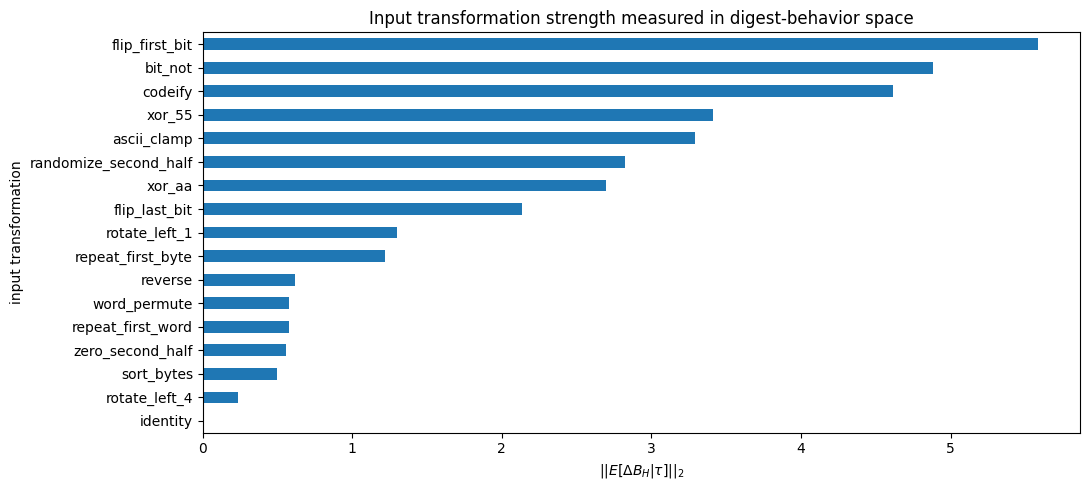

In [7]:
# Plot transform deformation magnitudes

plt.figure(figsize=(11, 5))
summary["mean_delta_norm"].sort_values().plot(kind="barh")
plt.title("Input transformation strength measured in digest-behavior space")
plt.xlabel(r"$||E[\Delta B_H|\tau]||_2$")
plt.ylabel("input transformation")
plt.tight_layout()
plt.show()


## 6. Heatmap of transfer grammar

Rows are input verbs $\tau$.

Columns are digest-behavior components.


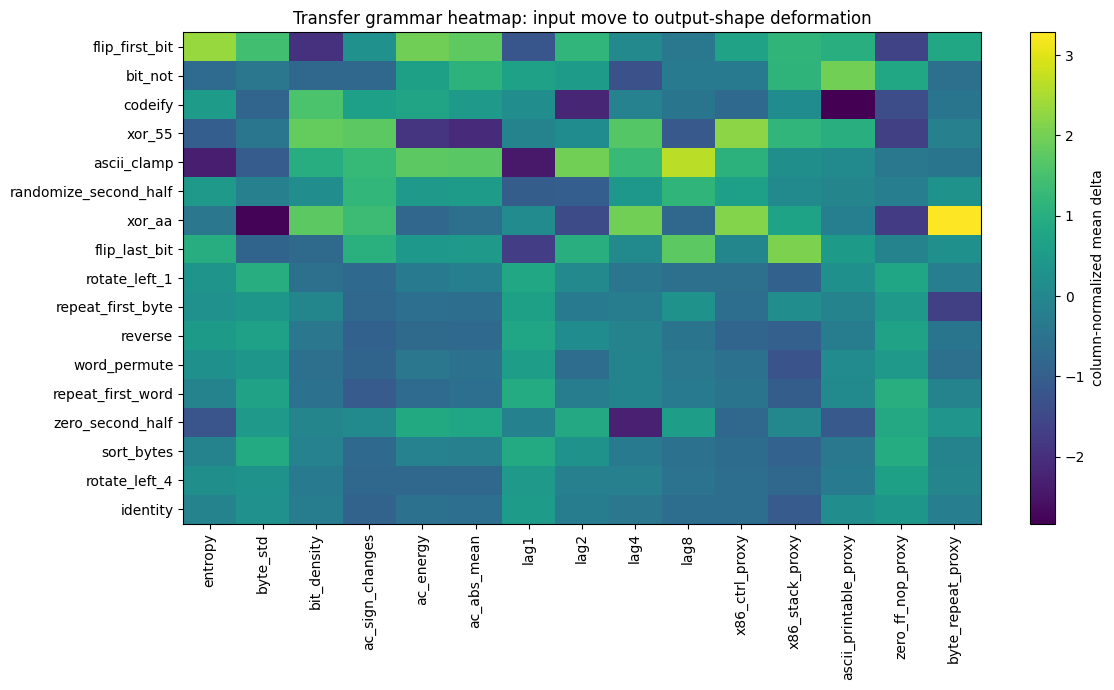

In [8]:
# Heatmap of transform signatures

compact_delta_cols = [
    "d_entropy", "d_byte_std", "d_bit_density", "d_ac_sign_changes",
    "d_ac_energy", "d_ac_abs_mean", "d_lag1", "d_lag2", "d_lag4", "d_lag8",
    "d_x86_ctrl_proxy", "d_x86_stack_proxy", "d_ascii_printable_proxy",
    "d_zero_ff_nop_proxy", "d_byte_repeat_proxy",
]

heat = agg.loc[summary.index, compact_delta_cols].copy()
heat_z = (heat - heat.mean(axis=0)) / (heat.std(axis=0).replace(0, 1))

plt.figure(figsize=(12, 7))
plt.imshow(heat_z.values, aspect="auto")
plt.colorbar(label="column-normalized mean delta")
plt.yticks(range(len(heat_z.index)), heat_z.index)
plt.xticks(range(len(heat_z.columns)), [c.replace("d_", "") for c in heat_z.columns], rotation=90)
plt.title("Transfer grammar heatmap: input move to output-shape deformation")
plt.tight_layout()
plt.show()


## 7. Domain-conditioned grammar

The same input move can echo differently depending on the source measure:

$$
\mathbb E[\Delta B_H\mid \tau,\mu_D].
$$


In [9]:
# Domain-conditioned response

domain_transform_norm = (
    transfer_df
    .groupby(["domain", "transform"])[delta_cols]
    .mean()
    .apply(lambda row: float(np.sqrt(np.dot(row, row))), axis=1)
    .unstack("transform")
)

domain_transform_norm.round(4)


transform,ascii_clamp,bit_not,codeify,flip_first_bit,flip_last_bit,identity,randomize_second_half,repeat_first_byte,repeat_first_word,reverse,rotate_left_1,rotate_left_4,sort_bytes,word_permute,xor_55,xor_aa,zero_second_half
domain,,,,,,,,,,,,,,,,,
code_like,1.1225,1.9655,1.7370,1.0034,1.1592,0.0,3.1753,2.7701,2.2087,2.2826,2.3712,0.6763,4.8288,1.8959,1.5369,1.2763,2.6177
ff,7.6968,7.3581,18.0789,7.7254,5.5974,0.0,7.3383,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,11.8154,15.4511,24.8003
nop,19.1422,41.9543,0.0000,42.4744,32.7563,0.0,29.2713,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,35.9483,13.5260,32.6138
random,3.1846,0.8681,1.3129,1.5921,1.8220,0.0,4.6277,1.5651,1.0361,0.5433,2.0499,2.3183,2.7759,1.3433,0.5042,0.5258,5.7702
repeated_byte,2.2436,2.8505,7.8967,2.3217,2.6109,0.0,2.2087,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.8890,3.3885,5.0842
repeated_word,4.4709,3.0642,1.0087,3.8721,1.4464,0.0,4.3559,2.6257,0.0000,5.0025,7.6953,0.0000,3.7041,0.0000,2.4195,4.9878,1.9255
text,3.5133,2.5847,5.3665,5.7548,4.7085,0.0,0.7350,9.2948,5.3326,1.0692,2.9446,5.8753,2.7617,3.1147,5.9042,1.9214,1.9455
tone,2.0170,1.6539,2.7777,1.8890,2.5787,0.0,3.9591,0.5617,1.4571,2.9332,1.6317,2.1846,1.9517,1.1206,1.9359,1.2403,3.0796
zero,19.6784,7.3581,29.1521,11.5283,28.9634,0.0,12.7331,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,18.2139,18.4514,0.0000


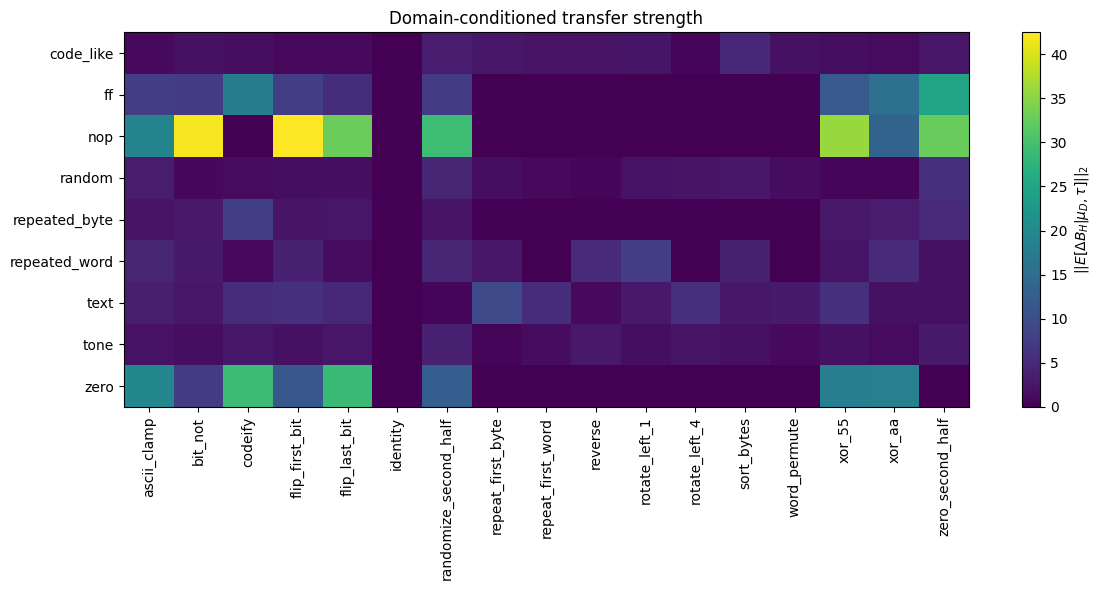

In [10]:
plt.figure(figsize=(12, 6))
plt.imshow(domain_transform_norm.values, aspect="auto")
plt.colorbar(label=r"$||E[\Delta B_H|\mu_D,\tau]||_2$")
plt.yticks(range(len(domain_transform_norm.index)), domain_transform_norm.index)
plt.xticks(range(len(domain_transform_norm.columns)), domain_transform_norm.columns, rotation=90)
plt.title("Domain-conditioned transfer strength")
plt.tight_layout()
plt.show()


## 8. Low-dimensional transfer map

Use PCA via SVD on $\Delta B_H$ to see whether input verbs occupy distinct regions in output-behavior space.


In [11]:
# PCA/SVD of transfer deltas

X = transfer_df[delta_cols].values.astype(float)
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)
X_std[X_std == 0] = 1
Z = (X - X_mean) / X_std

U, S, Vt = np.linalg.svd(Z, full_matrices=False)
coords = U[:, :2] * S[:2]
transfer_df["pc1"] = coords[:, 0]
transfer_df["pc2"] = coords[:, 1]

explained = (S**2) / np.sum(S**2)
print("Explained variance first 5 PCs:", np.round(explained[:5], 4))


Explained variance first 5 PCs: [0.1026 0.0898 0.0672 0.0612 0.0585]


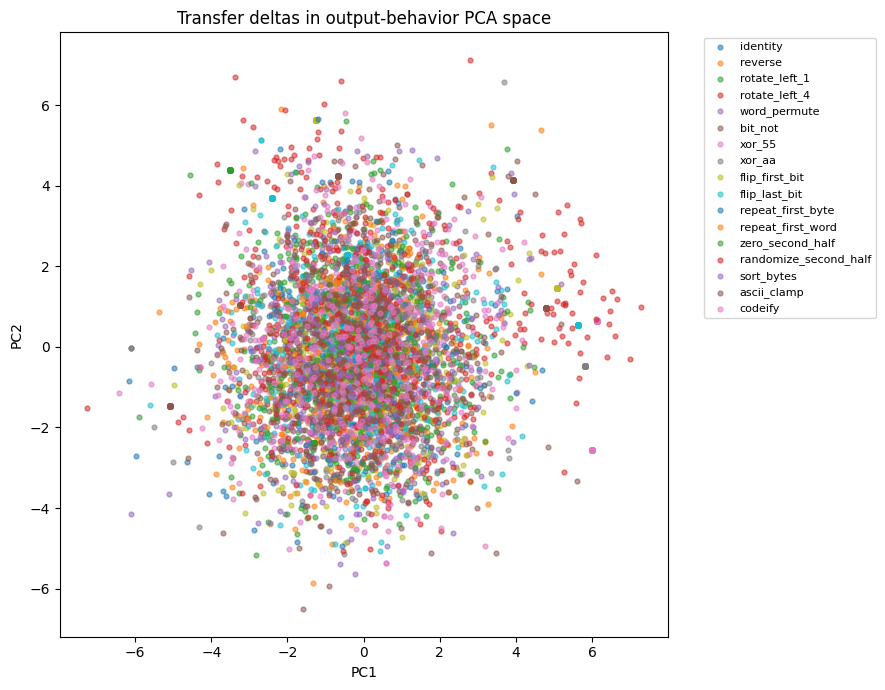

In [12]:
# Scatter by transform using matplotlib defaults

plt.figure(figsize=(9, 7))
for tname in TRANSFORMS:
    sub = transfer_df[transfer_df["transform"] == tname]
    plt.scatter(sub["pc1"], sub["pc2"], s=12, alpha=0.55, label=tname)
plt.title("Transfer deltas in output-behavior PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 9. Transform recognition from $\Delta B_H$

A transfer grammar is useful if output deformation carries information about the input move:

$$
\Delta B_H \rightarrow \hat{\tau}.
$$


In [13]:
# Simple train/test split and nearest-centroid transform classifier

def train_test_split_df(df: pd.DataFrame, test_frac: float = 0.25, key_cols=("domain", "transform")):
    train_parts = []
    test_parts = []
    for _, group in df.groupby(list(key_cols)):
        idxs = list(group.index)
        random.shuffle(idxs)
        n_test = max(1, int(round(len(idxs) * test_frac)))
        test_idx = idxs[:n_test]
        train_idx = idxs[n_test:]
        train_parts.append(df.loc[train_idx])
        test_parts.append(df.loc[test_idx])
    return pd.concat(train_parts), pd.concat(test_parts)

train_df, test_df = train_test_split_df(transfer_df, test_frac=0.25)

mu = train_df[delta_cols].mean()
sd = train_df[delta_cols].std().replace(0, 1)

train_Z = (train_df[delta_cols] - mu) / sd
test_Z = (test_df[delta_cols] - mu) / sd

centroids = train_Z.join(train_df["transform"]).groupby("transform").mean()

def predict_nearest_centroid(zrow: np.ndarray, centroids_df: pd.DataFrame) -> str:
    C = centroids_df.values
    d = np.sum((C - zrow) ** 2, axis=1)
    return str(centroids_df.index[int(np.argmin(d))])

preds = []
for i in range(len(test_Z)):
    preds.append(predict_nearest_centroid(test_Z.iloc[i].values, centroids))

test_eval = test_df.copy()
test_eval["pred_transform"] = preds
acc = float((test_eval["pred_transform"] == test_eval["transform"]).mean())

print(f"Nearest-centroid transform recognition accuracy: {acc:.3f}")
print(f"Random baseline: {1/len(TRANSFORMS):.3f}")
pd.crosstab(test_eval["transform"], test_eval["pred_transform"], normalize="index").round(2)


Nearest-centroid transform recognition accuracy: 0.170
Random baseline: 0.059


pred_transform,ascii_clamp,bit_not,codeify,flip_first_bit,flip_last_bit,identity,randomize_second_half,repeat_first_byte,repeat_first_word,reverse,rotate_left_1,rotate_left_4,sort_bytes,word_permute,xor_55,xor_aa,zero_second_half
transform,,,,,,,,,,,,,,,,,
ascii_clamp,0.39,0.10,0.06,0.08,0.01,0.00,0.03,0.05,0.03,0.00,0.01,0.04,0.01,0.03,0.03,0.04,0.08
bit_not,0.05,0.16,0.09,0.06,0.05,0.00,0.03,0.09,0.01,0.01,0.02,0.01,0.01,0.03,0.18,0.03,0.17
codeify,0.07,0.06,0.30,0.05,0.06,0.12,0.06,0.05,0.03,0.00,0.01,0.01,0.01,0.00,0.02,0.06,0.10
flip_first_bit,0.03,0.09,0.08,0.38,0.04,0.00,0.05,0.06,0.03,0.01,0.02,0.01,0.02,0.02,0.03,0.03,0.09
flip_last_bit,0.16,0.08,0.12,0.17,0.01,0.00,0.04,0.06,0.01,0.01,0.03,0.01,0.00,0.01,0.06,0.17,0.06
identity,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
randomize_second_half,0.18,0.08,0.10,0.10,0.05,0.00,0.03,0.07,0.03,0.01,0.01,0.01,0.00,0.01,0.12,0.10,0.10
repeat_first_byte,0.08,0.07,0.07,0.04,0.01,0.44,0.03,0.08,0.01,0.00,0.01,0.00,0.00,0.01,0.02,0.03,0.10
repeat_first_word,0.04,0.04,0.05,0.03,0.01,0.56,0.01,0.04,0.01,0.00,0.02,0.02,0.01,0.02,0.03,0.06,0.03


## 10. Domain recognition from $B(H)$

Test:

$$
B(H)\rightarrow \hat{\mu}_D.
$$

This checks whether digest behavior carries source-measure signal. It is not parameter recovery.


In [14]:
# Nearest-centroid domain classifier on base B(H)

def split_base_by_domain(df: pd.DataFrame, test_frac: float = 0.25):
    train_parts = []
    test_parts = []
    for _, group in df.groupby("domain"):
        idxs = list(group.index)
        random.shuffle(idxs)
        n_test = max(1, int(round(len(idxs) * test_frac)))
        test_parts.append(df.loc[idxs[:n_test]])
        train_parts.append(df.loc[idxs[n_test:]])
    return pd.concat(train_parts), pd.concat(test_parts)

base_train, base_test = split_base_by_domain(base_df, 0.25)

mu_b = base_train[feature_cols].mean()
sd_b = base_train[feature_cols].std().replace(0, 1)
base_train_Z = (base_train[feature_cols] - mu_b) / sd_b
base_test_Z = (base_test[feature_cols] - mu_b) / sd_b

domain_centroids = base_train_Z.join(base_train["domain"]).groupby("domain").mean()

domain_preds = [
    predict_nearest_centroid(base_test_Z.iloc[i].values, domain_centroids)
    for i in range(len(base_test_Z))
]

domain_eval = base_test.copy()
domain_eval["pred_domain"] = domain_preds
domain_acc = float((domain_eval["pred_domain"] == domain_eval["domain"]).mean())

print(f"Nearest-centroid domain recognition accuracy from B(H): {domain_acc:.3f}")
print(f"Random baseline: {1/len(GENERATORS):.3f}")
pd.crosstab(domain_eval["domain"], domain_eval["pred_domain"], normalize="index").round(2)


Nearest-centroid domain recognition accuracy from B(H): 0.438
Random baseline: 0.111


pred_domain,code_like,ff,nop,random,repeated_byte,repeated_word,text,tone,zero
domain,,,,,,,,,
code_like,0.12,0.0,0.06,0.12,0.12,0.19,0.19,0.19,0.0
ff,0.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0
nop,0.00,0.0,1.00,0.00,0.00,0.00,0.00,0.00,0.0
random,0.12,0.0,0.00,0.25,0.06,0.19,0.12,0.25,0.0
repeated_byte,0.19,0.0,0.00,0.44,0.06,0.06,0.06,0.19,0.0
repeated_word,0.38,0.0,0.00,0.12,0.06,0.06,0.12,0.25,0.0
text,0.19,0.0,0.00,0.06,0.12,0.12,0.19,0.31,0.0
tone,0.06,0.0,0.00,0.25,0.06,0.19,0.19,0.25,0.0
zero,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,1.0


## 11. One-bit avalanche as a transfer verb

A one-bit flip is the smallest input move:

$$
\tau_b(M)=M\oplus e_b.
$$

Avalanche says the digest changes globally. The transfer grammar asks what **kind** of behavior-space motion that global change produces.


In [15]:
# One-bit avalanche experiment

def flip_bit_in_message(m: bytes, bit_index: int) -> bytes:
    out = bytearray(m)
    byte_i = bit_index // 8
    bit_i = 7 - (bit_index % 8)  # big-endian bit position inside byte
    out[byte_i] ^= (1 << bit_i)
    return bytes(out)

av_rows = []
for domain, idx, msg in base_messages[: min(len(base_messages), 300)]:
    bit_index = random.randrange(len(msg) * 8)
    msg2 = flip_bit_in_message(msg, bit_index)
    h0 = sha256_bytes(msg)
    h1 = sha256_bytes(msg2)
    digest_hd = sum((a ^ b).bit_count() for a, b in zip(h0, h1))
    B0 = B_of_digest(h0)
    B1 = B_of_digest(h1)
    row = {
        "domain": domain,
        "idx": idx,
        "bit_index": bit_index,
        "digest_hamming": digest_hd,
    }
    for c in feature_cols:
        row[f"d_{c}"] = B1[c] - B0[c]
    av_rows.append(row)

av_df = pd.DataFrame(av_rows)
av_df["delta_norm"] = np.sqrt((av_df[[f"d_{c}" for c in feature_cols]] ** 2).sum(axis=1))

print("Digest avalanche HW summary")
print(av_df["digest_hamming"].describe().round(3))
print()
print("Behavior delta norm by domain")
av_df.groupby("domain")["delta_norm"].describe().round(3)


Digest avalanche HW summary
count    300.000
mean     127.917
std        7.692
min      109.000
25%      123.000
50%      128.000
75%      133.000
max      147.000
Name: digest_hamming, dtype: float64

Behavior delta norm by domain


,count,mean,std,min,25%,50%,75%,max
domain,,,,,,,,
ff,64.0,12.624,6.694,2.416,7.282,11.387,17.263,31.910
nop,64.0,26.309,12.528,7.043,16.537,24.550,35.123,53.896
random,64.0,18.995,11.443,4.172,10.821,15.221,25.474,53.230
repeated_byte,44.0,15.927,9.668,2.420,8.342,14.383,21.216,52.333
zero,64.0,18.442,9.013,5.106,10.712,18.197,23.313,48.696


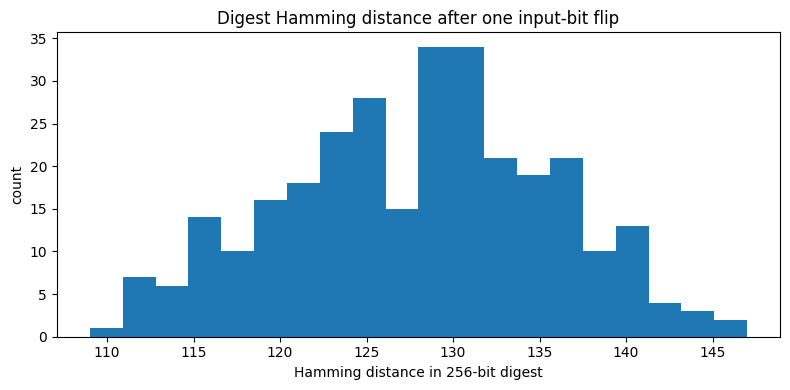

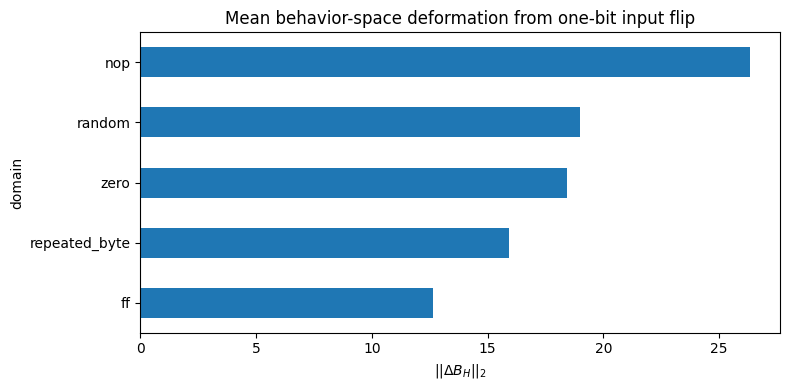

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(av_df["digest_hamming"], bins=20)
plt.title("Digest Hamming distance after one input-bit flip")
plt.xlabel("Hamming distance in 256-bit digest")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
av_df.groupby("domain")["delta_norm"].mean().sort_values().plot(kind="barh")
plt.title("Mean behavior-space deformation from one-bit input flip")
plt.xlabel(r"$||\Delta B_H||_2$")
plt.ylabel("domain")
plt.tight_layout()
plt.show()


## 12. Export the grammar tables

The notebook writes three CSV files when run:

1. `sha_transfer_base_features.csv`
2. `sha_transfer_delta_grammar.csv`
3. `sha_transfer_transform_summary.csv`


In [17]:
# Export artifacts

base_path = "sha_transfer_base_features.csv"
transfer_path = "sha_transfer_delta_grammar.csv"
summary_path = "sha_transfer_transform_summary.csv"

base_df.to_csv(base_path, index=False)
transfer_df.to_csv(transfer_path, index=False)
summary.to_csv(summary_path)

print("Exported:")
print(base_path)
print(transfer_path)
print(summary_path)


Exported:
sha_transfer_base_features.csv
sha_transfer_delta_grammar.csv
sha_transfer_transform_summary.csv


# Final Ψ-collapse

This notebook builds the external grammar rail:

$$
\boxed{
\text{input move}\rightarrow\text{output deformation}
}
$$

The central object is:

$$
\boxed{
\Delta B_H(\tau;M)=B(H(\tau(M)))-B(H(M)).
}
$$

This lets us ask:

- Which input transformations produce stable output echoes?
- Which source domains condition those echoes?
- Which output features respond to repetition, permutation, rotation, randomization, and coding/textification?
- Does $B(H)$ carry source-template signal without claiming direct parameter recovery?

The notebook avoids false internal inversion. It treats SHA-256 as a transfer surface first, and only later uses internals as explanatory anatomy.

$$
\boxed{
\text{Stop chasing unavailable internal states. Learn the transfer grammar.}
}
$$
